# STAGE 1: Frame & KPIs

**Business Question:** How can we segment our customer base using their purchasing behavior (Recency, Frequency, and Monetary value) to identify high-value, at-risk, and low-engagement groups for targeted marketing?

**Decision-Maker:** Head of Marketing / CRM Manager (They will use these segments to allocate budget and tailor specific email/ad campaigns).

**Success Metric and KPIs:**
* **Primary Success Metric (Business):** Launch of distinct, customized marketing campaigns for each identified segment, aiming to increase the retention rate of 'at-risk' customers.
* **KPI 1 (Technical):** Silhouette Score > 0.5, measured on a held-out set of customers the model did not see during training (not just on the training data used to fit it).
* **KPI 2 (Business):** Conversion rate of segment-specific promotional campaigns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility (Rubric requirement)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Load the dataset using a relative path
df = pd.read_excel('Online Retail.xlsx')

# Check that the data loaded correctly
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# STAGE 2: Prepare data (EDA, Cleaning & Features)

To build a reliable RFM (Recency, Frequency, Monetary) segmentation model, we need to process the raw transactional data into customer-level metrics.

**Data Cleaning & Quality Steps:**
* **Duplicates:** We removed exact duplicate rows, most likely artifacts from the data extraction process.
* **Missing Values:** We dropped records with missing `CustomerID` as they cannot be assigned to a specific user for segmentation.
* **Outliers & Anomalies:** We filtered out negative quantities (returns/cancellations) and zero-pricing errors to avoid distorting the Monetary value.
* **Feature Engineering:** We created a `TotalAmount` column (Quantity * UnitPrice) and aggregated the data per customer to calculate Recency (days since last purchase), Frequency (number of unique transactions), and Monetary (total spend). Leakage is avoided as we are strictly using historical behavioral data.

In [2]:
# ==============================================================================
# 1. DATA CLEANING (Duplicates, Missing Values & Outliers)
# ==============================================================================
# Remove exact duplicate rows (likely an extraction artifact)
df_clean = df.drop_duplicates().copy()

# Remove rows with no CustomerID (they cannot be assigned to a customer)
df_clean = df_clean.dropna(subset=['CustomerID'])

# Remove returns (negative quantities) and zero or negative prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]


# ==============================================================================
# 2. FEATURE ENGINEERING
# ==============================================================================
# Total amount spent on each transaction line
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Make sure the date column has the correct datetime format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])


# ==============================================================================
# 3. BUILDING THE R-F-M VARIABLES
# ==============================================================================
# Reference "today": one day after the last transaction observed in the data
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by CustomerID and compute Recency, Frequency and Monetary
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency: days since last purchase
    'InvoiceNo': 'nunique',                                   # Frequency: number of distinct invoices
    'TotalAmount': 'sum'                                      # Monetary: total spend
}).reset_index()

# Rename the columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

# Show the prepared dataset that feeds the model
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


# STAGE 3: Model & evaluate

**Modeling Approach:**
We selected **K-Means Clustering** to segment our customers based on their RFM behavior. Since K-Means is a distance-based algorithm, we first scaled the features using `StandardScaler` to ensure Recency, Frequency, and Monetary values contribute equally to the distance calculations.

**Validation strategy (train / test split):**
K-Means has no labeled target, so there is nothing to "leak" in the traditional sense — but the model can still overfit to the specific customers it was fitted on. To check this honestly, we split customers into an 80% **train** set and a 20% **test** set *before* scaling. The scaler and the K-Means model are fitted **only on train**; the test customers are never used to fit anything, only to *predict* on and *evaluate*. If the segmentation reflects real structure and not noise, the silhouette score on the unseen test customers should be close to the one on train.

**Choosing k:**
Our business framing (STAGE 1) calls for three profiles: high-value, at-risk, and low-engagement. We check that choice against the data using the elbow method (inertia) and the silhouette score across a range of k values, computed on the training set only.

**Baseline:**
A silhouette score alone doesn't tell us whether K-Means is actually adding value. We compare it against a simple **RFM quintile scoring** baseline — the traditional, non-ML method a marketing team could apply without any model — evaluated on the same held-out test customers.

**Evaluation Metric:**
We use the **Silhouette Score** (how similar a customer is to its own cluster vs. the nearest other cluster) as our technical KPI, targeting > 0.5 as defined in STAGE 1.

In [3]:
# ==============================================================================
# 1. TRAIN / TEST SPLIT (before scaling, so that no information leaks)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = ['Recency', 'Frequency', 'Monetary']

rfm_train, rfm_test = train_test_split(rfm, test_size=0.2, random_state=RANDOM_SEED)

# ==============================================================================
# 2. SCALING (fit ONLY on train, transform on test)
# ==============================================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(rfm_train[FEATURES])   # fit + transform on train
X_test  = scaler.transform(rfm_test[FEATURES])        # transform ONLY on test, never fit

print(f'Training customers: {len(rfm_train)}')
print(f'Test customers    : {len(rfm_test)}')

Training customers: 3470
Test customers    : 868


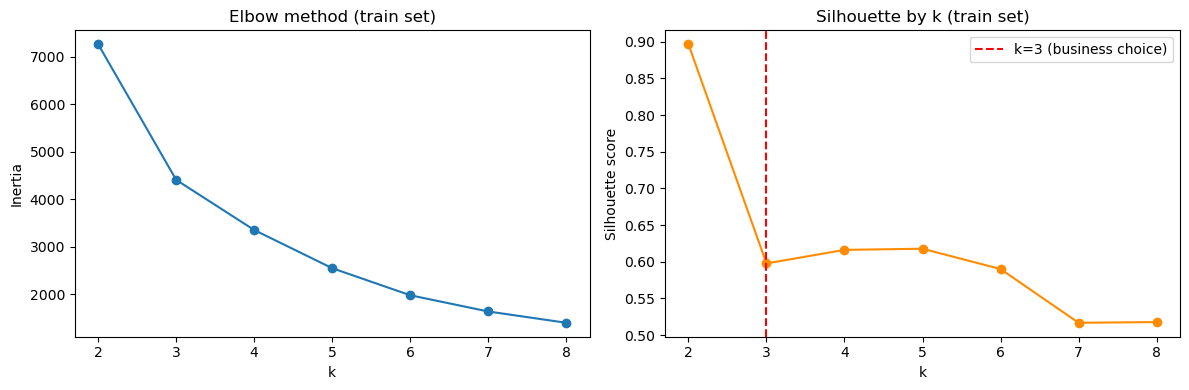

k with the highest silhouette (statistics only): 2  (score = 0.8966)
k chosen from the business framing (STAGE 1)   : 3  (score = 0.5978)

We choose k=3 because it matches the three marketing profiles the business can
actually operate (high-value, at-risk, low-engagement), even if it is not the
statistical optimum. The cost of that decision, in silhouette points, is shown above.


In [4]:
# ==============================================================================
# 3. CHOOSING k: ELBOW + SILHOUETTE (computed on the training set only)
# ==============================================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 9)
inertias = []
silhouettes = []

for k_candidate in k_range:
    km = KMeans(n_clusters=k_candidate, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_train)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method (train set)')

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange')
axes[1].axvline(3, color='red', linestyle='--', label='k=3 (business choice)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette by k (train set)')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouettes))]
sil_at_3 = silhouettes[list(k_range).index(3)]
print(f'k with the highest silhouette (statistics only): {best_k}  (score = {max(silhouettes):.4f})')
print(f'k chosen from the business framing (STAGE 1)   : 3  (score = {sil_at_3:.4f})')
print('\nWe choose k=3 because it matches the three marketing profiles the business can')
print('actually operate (high-value, at-risk, low-engagement), even if it is not the')
print('statistical optimum. The cost of that decision, in silhouette points, is shown above.')

In [5]:
# ==============================================================================
# 4. TRAIN WITH k=3 (chosen in STAGE 1) AND VALIDATE ON THE HELD-OUT SET
# ==============================================================================
k = 3
kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
kmeans.fit(X_train)                      # fit ONLY on train

train_labels = kmeans.labels_
test_labels  = kmeans.predict(X_test)    # predict, NEVER fit, on test

sil_train = silhouette_score(X_train, train_labels)
sil_test  = silhouette_score(X_test, test_labels)

print(f'Silhouette Score on TRAIN                   : {sil_train:.4f}')
print(f'Silhouette Score on TEST (unseen customers) : {sil_test:.4f}')
print(f'Difference train -> test                    : {sil_train - sil_test:+.4f}  '
      f'(the smaller it is, the better the model generalises)')

if sil_test > 0.5:
    print('\nTechnical KPI MET on unseen data: the clusters are well defined')
    print('and clearly distinct from each other.')
else:
    print('\nTechnical KPI not fully met on unseen data. The clusters can still be')
    print('business-actionable, but the boundaries between neighbouring segments')
    print('are softer than expected.')

print('\nCustomers per cluster (train):')
print(pd.Series(train_labels).value_counts().sort_index())

Silhouette Score on TRAIN                   : 0.5978
Silhouette Score on TEST (unseen customers) : 0.5676
Difference train -> test                    : +0.0301  (the smaller it is, the better the model generalises)

Technical KPI MET on unseen data: the clusters are well defined
and clearly distinct from each other.

Customers per cluster (train):
0     853
1      21
2    2596
Name: count, dtype: int64


In [6]:
# ==============================================================================
# 5. BASELINE: RFM quintile scoring (traditional method, no Machine Learning)
# ==============================================================================
def rfm_quintile_baseline(frame, n_groups=k):
    # Replicates what a marketing team would do by hand: rank every customer
    # into quintiles on R, F and M, add the three scores, and cut the result
    # into n_groups. Used as the reference point for K-Means.
    scored = pd.DataFrame(index=frame.index)
    # Recency: FEWER days is better, so the ranking is reversed
    scored['R'] = pd.qcut(frame['Recency'].rank(method='first', ascending=False), 5, labels=False)
    scored['F'] = pd.qcut(frame['Frequency'].rank(method='first'), 5, labels=False)
    scored['M'] = pd.qcut(frame['Monetary'].rank(method='first'), 5, labels=False)
    total = scored[['R', 'F', 'M']].sum(axis=1)
    return pd.qcut(total.rank(method='first'), n_groups, labels=False).values

baseline_labels = rfm_quintile_baseline(rfm_test[FEATURES])
sil_baseline = silhouette_score(X_test, baseline_labels)

comparison = pd.DataFrame({
    'Method': ['RFM quintile scoring (traditional baseline)', f'K-Means (k={k})'],
    'Silhouette on test': [sil_baseline, sil_test],
})
print(comparison.to_string(index=False))
print(f'\nImprovement of K-Means over the traditional baseline: '
      f'{sil_test - sil_baseline:+.4f} silhouette points')
print('(both evaluated on the same test customers, so the comparison is fair)')

                                     Method  Silhouette on test
RFM quintile scoring (traditional baseline)            0.097248
                              K-Means (k=3)            0.567624

Improvement of K-Means over the traditional baseline: +0.4704 silhouette points
(both evaluated on the same test customers, so the comparison is fair)


In [7]:
# ==============================================================================
# 6. ASSIGN A SEGMENT TO EVERY CUSTOMER
# ==============================================================================
# The model is NOT re-trained here. We only apply (transform + predict) the
# pipeline already fitted on train to the full customer base, so that every
# customer -- those in train and those in test -- ends up with a segment.
X_all = scaler.transform(rfm[FEATURES])
rfm['Cluster'] = kmeans.predict(X_all)

# ==============================================================================
# 7. NAME THE SEGMENTS AUTOMATICALLY
# ==============================================================================
# Instead of reading the table and assuming by hand that "cluster 0 is Champions",
# the name is derived from each cluster's own averages. This keeps the notebook
# correct even if the cluster order changes when it is re-run.
cluster_means = rfm.groupby('Cluster')[FEATURES].mean()

# Composite score: high Frequency + high Monetary + LOW Recency = best customer
composite = (
    cluster_means['Frequency'].rank()
    + cluster_means['Monetary'].rank()
    + cluster_means['Recency'].rank(ascending=False)
)
ranked_clusters = composite.sort_values(ascending=False).index.tolist()

# Note: these 3 names match the 3 profiles defined in STAGE 1 (k=3).
# If the number of clusters changed, this list would need to be adjusted.
SEGMENT_NAMES = ['High-Value / Champions', 'At-Risk / Need Attention', 'Low-Engagement / Lost']
cluster_to_segment = {cluster: SEGMENT_NAMES[i] for i, cluster in enumerate(ranked_clusters)}

rfm['Segment'] = rfm['Cluster'].map(cluster_to_segment)

print('Cluster -> Segment (assigned automatically from each cluster own averages):')
for cluster_id in sorted(cluster_to_segment):
    print(f'  Cluster {cluster_id} -> {cluster_to_segment[cluster_id]}')

Cluster -> Segment (assigned automatically from each cluster own averages):
  Cluster 0 -> Low-Engagement / Lost
  Cluster 1 -> High-Value / Champions
  Cluster 2 -> At-Risk / Need Attention


# STAGE 4: Communicate

We now visualize and profile the three segments identified above. Because the segments were named automatically from their own averages (STAGE 3), the labels below stay correct even if you re-run the notebook and the underlying cluster numbers change.

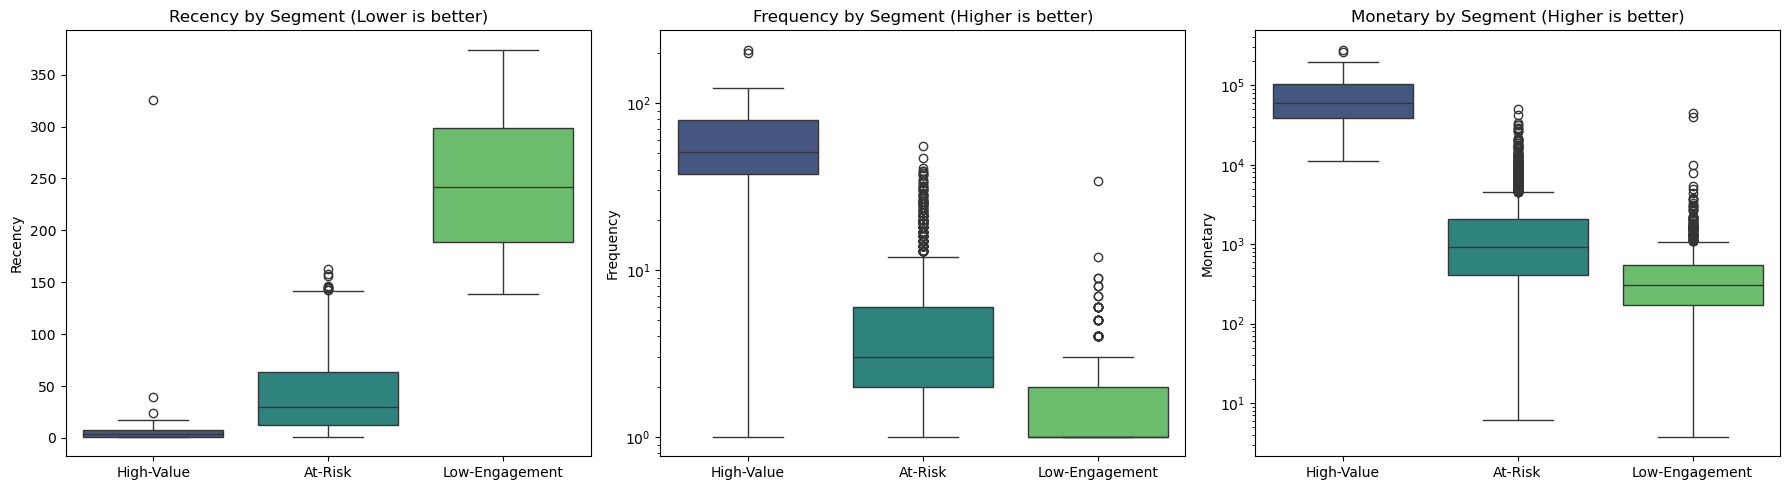

,Recency,Frequency,Monetary,Count
Segment,,,,
High-Value / Champions,17.89,64.00,85505.99,27
At-Risk / Need Attention,41.45,4.67,1849.67,3230
Low-Engagement / Lost,247.03,1.58,558.85,1081


In [8]:
# ==============================================================================
# STAGE 4: Communicate - Visualizing and Profiling Clusters
# ==============================================================================
import seaborn as sns

# Same order as above: Champions -> At-Risk -> Low-Engagement
segment_order = SEGMENT_NAMES
short_labels = [s.split(' / ')[0] for s in segment_order]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Segment', y='Recency', data=rfm, order=segment_order,
            hue='Segment', hue_order=segment_order, palette='viridis',
            legend=False, ax=axes[0])
axes[0].set_title('Recency by Segment (Lower is better)')

sns.boxplot(x='Segment', y='Frequency', data=rfm, order=segment_order,
            hue='Segment', hue_order=segment_order, palette='viridis',
            legend=False, ax=axes[1])
axes[1].set_title('Frequency by Segment (Higher is better)')
axes[1].set_yscale('log')   # Log scale so the extreme values stay readable

sns.boxplot(x='Segment', y='Monetary', data=rfm, order=segment_order,
            hue='Segment', hue_order=segment_order, palette='viridis',
            legend=False, ax=axes[2])
axes[2].set_title('Monetary by Segment (Higher is better)')
axes[2].set_yscale('log')

for ax in axes:
    ax.set_xticks(range(len(short_labels)))
    ax.set_xticklabels(short_labels)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

# Average numerical profile, labelled by segment name rather than cluster number
cluster_summary = rfm.groupby('Segment')[FEATURES].mean().round(2).loc[segment_order]
cluster_summary['Count'] = rfm.groupby('Segment')['CustomerID'].count().loc[segment_order]
display(cluster_summary)

### Business Interpretation & Actionable Recommendations

The three segments below were assigned automatically in STAGE 3, based on each cluster's own average Recency, Frequency and Monetary values — no manual guessing required, even after re-running the notebook.

* **High-Value / Champions:** These customers bought recently, buy often, and spend the most.
    * **Recommendation:** Reward them. Offer early access to new products, exclusive loyalty programs, and VIP customer service to maintain their high engagement.
* **At-Risk / Need Attention:** Customers with decent frequency and monetary value, but a high Recency (they haven't purchased in a while).
    * **Recommendation:** Win them back. Send highly targeted re-engagement emails with limited-time discount codes or personalized recommendations based on their past purchases.
* **Low-Engagement / Lost:** High recency, very low frequency, and low monetary value.
    * **Recommendation:** Limit marketing spend on this group. Use generic, automated newsletters rather than expensive targeted ads to maximize ROI.

### Dashboard

The cells below build a **self-contained HTML dashboard** (`dashboard.html`) with the charts embedded directly in the file, so it opens in any browser with no server and no external files. It is regenerated from the notebook on every run, so it can never drift out of sync with the analysis.

In [9]:
# ==============================================================================
# STAGE 4: Communicate - Self-contained HTML dashboard
# ==============================================================================
# The dashboard is regenerated from the notebook on every run, so it can never
# drift out of sync with the analysis. Images are embedded as base64, which means
# the .html file opens in any browser with no server and no external files.
import base64
import io

def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode('utf-8')

PALETTE = ['#0B6E6E', '#D98C1F', '#A6484A']

# --- Chart A: share of customers vs share of revenue
revenue_by_segment = rfm.groupby('Segment')['Monetary'].sum().loc[segment_order]
pct_customers = (cluster_summary['Count'] / cluster_summary['Count'].sum() * 100)
pct_revenue   = (revenue_by_segment / revenue_by_segment.sum() * 100)

figA, ax = plt.subplots(figsize=(8, 4))
xpos = np.arange(len(segment_order)); width = 0.38
ax.bar(xpos - width/2, pct_customers.values, width, label='% of customers', color='#3E6B9B')
ax.bar(xpos + width/2, pct_revenue.values,   width, label='% of revenue',   color='#D98C1F')
ax.set_xticks(xpos)
ax.set_xticklabels([s.split(' / ')[0] for s in segment_order])
ax.set_ylabel('%')
ax.set_title('Customer share vs revenue share')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
chartA = fig_to_base64(figA)

# --- Chart B: average spend per customer
figB, ax = plt.subplots(figsize=(8, 4))
ax.bar([s.split(' / ')[0] for s in segment_order],
       cluster_summary['Monetary'].values, color=PALETTE)
ax.set_ylabel('GBP')
ax.set_title('Average spend per customer')
ax.grid(axis='y', alpha=0.25)
for i, v in enumerate(cluster_summary['Monetary'].values):
    ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)
chartB = fig_to_base64(figB)

print('Charts encoded for the dashboard.')

Charts encoded for the dashboard.


In [10]:
# Marketing treatment assigned to each segment
SEGMENT_ACTIONS = {
    'High-Value / Champions':   'Loyalty rewards and early access. No discounts.',
    'At-Risk / Need Attention': 'Win-back campaign: personal contact + time-limited offer.',
    'Low-Engagement / Lost':    'Low-cost automated newsletter only. Stop paid contact.',
}
print('Marketing action defined for each segment.')

Marketing action defined for each segment.


In [11]:
# --- Build the segment table rows
rows_html = ''
for seg in segment_order:
    r = cluster_summary.loc[seg]
    rows_html += (
        '<tr>'
        f"<td class='seg'>{seg}</td>"
        f"<td>{r['Count']:,.0f}</td>"
        f"<td>{pct_customers[seg]:.1f}%</td>"
        f"<td>{r['Recency']:.0f}</td>"
        f"<td>{r['Frequency']:.1f}</td>"
        f"<td>&pound;{r['Monetary']:,.0f}</td>"
        f"<td>{pct_revenue[seg]:.1f}%</td>"
        f"<td class='act'>{SEGMENT_ACTIONS[seg]}</td>"
        '</tr>'
    )

CSS = (
    'body{font-family:-apple-system,Segoe UI,Roboto,sans-serif;margin:0;'
    'background:#f4f6f7;color:#1b2b2b;}'
    'header{background:#0B6E6E;color:#fff;padding:26px 34px;}'
    'header h1{margin:0 0 4px;font-size:24px;font-weight:600;}'
    'header p{margin:0;opacity:.85;font-size:13px;}'
    '.wrap{max-width:1100px;margin:0 auto;padding:26px 20px 50px;}'
    '.kpis{display:grid;grid-template-columns:repeat(auto-fit,minmax(190px,1fr));'
    'gap:14px;margin-bottom:26px;}'
    '.kpi{background:#fff;border-radius:8px;padding:18px 20px;'
    'border-left:4px solid #D98C1F;box-shadow:0 1px 3px rgba(0,0,0,.07);}'
    '.kpi .v{font-size:27px;font-weight:700;color:#0B6E6E;}'
    '.kpi .l{font-size:11px;text-transform:uppercase;letter-spacing:.7px;'
    'color:#67787a;margin-top:5px;}'
    '.card{background:#fff;border-radius:8px;padding:20px 24px;margin-bottom:20px;'
    'box-shadow:0 1px 3px rgba(0,0,0,.07);}'
    '.card h2{margin:0 0 14px;font-size:16px;color:#0B6E6E;'
    'border-bottom:2px solid #eef1f1;padding-bottom:8px;}'
    'img{max-width:100%;height:auto;display:block;}'
    'table{width:100%;border-collapse:collapse;font-size:13px;}'
    'th{background:#0B6E6E;color:#fff;padding:9px 10px;text-align:left;font-weight:600;}'
    'td{padding:9px 10px;border-bottom:1px solid #eef1f1;}'
    'tr:nth-child(even) td{background:#fafbfb;}'
    'td.seg{font-weight:700;color:#0B6E6E;}'
    'td.act{font-size:12px;color:#40585a;}'
    'footer{text-align:center;font-size:11px;color:#8a9a9c;padding:16px;}'
)

html = (
    "<!DOCTYPE html><html lang='en'><head><meta charset='utf-8'>"
    '<title>Customer Segmentation Dashboard | Team 4</title>'
    f'<style>{CSS}</style></head><body>'
    '<header><h1>Customer Segmentation Dashboard</h1>'
    '<p>Online Retail &middot; RFM K-Means segmentation &middot; Team 4 '
    '&middot; IIB415A Business Intelligence</p></header>'
    "<div class='wrap'>"

    "<div class='kpis'>"
    f"<div class='kpi'><div class='v'>{len(rfm):,}</div>"
    "<div class='l'>Customers segmented</div></div>"
    f"<div class='kpi'><div class='v'>&pound;{rfm['Monetary'].sum()/1e6:.2f}M</div>"
    "<div class='l'>Total revenue analysed</div></div>"
    f"<div class='kpi'><div class='v'>{pct_revenue[segment_order[0]]:.0f}%</div>"
    "<div class='l'>Revenue from Champions</div></div>"
    f"<div class='kpi'><div class='v'>{sil_test:.2f}</div>"
    "<div class='l'>Silhouette (held-out)</div></div>"
    '</div>'

    "<div class='card'><h2>Segments, profiles and recommended action</h2><table>"
    '<tr><th>Segment</th><th>Customers</th><th>% base</th><th>Recency (days)</th>'
    '<th>Orders</th><th>Avg spend</th><th>% revenue</th><th>Recommended action</th></tr>'
    f'{rows_html}</table></div>'

    "<div class='card'><h2>Customer share vs revenue share</h2>"
    f"<img src='data:image/png;base64,{chartA}' alt='Customer share versus revenue share'></div>"

    "<div class='card'><h2>Average spend per customer</h2>"
    f"<img src='data:image/png;base64,{chartB}' alt='Average spend per customer'></div>"

    '</div>'
    '<footer>Generated automatically from the project notebook &middot; '
    'Universidad del Desarrollo &middot; 2026</footer>'
    '</body></html>'
)

with open('dashboard.html', 'w', encoding='utf-8') as f:
    f.write(html)

print('dashboard.html written successfully.')
print('Open it in any browser - it is fully self-contained (images embedded).')

dashboard.html written successfully.
Open it in any browser - it is fully self-contained (images embedded).


# STAGE 5: Ethics & Limits

As a responsible Business Intelligence unit, we must acknowledge the ethical implications and limitations of this model before it is deployed by the Marketing team:

**1. Privacy & Data Handling:**
While the dataset does not contain explicit names, it tracks granular purchasing behavior and `CustomerID`s. This constitutes pseudo-anonymized data under regulations like GDPR. Marketing must ensure that cross-referencing these IDs with the CRM database is strictly access-controlled and that customers have opted in to receive targeted marketing.

**2. Bias & Fairness:**
The original Online Retail dataset is heavily skewed towards customers in the United Kingdom. Applying this segmentation strategy directly to a new market (e.g., South America or Asia) without retraining might lead to ineffective campaigns, as purchasing habits and seasonal trends differ.

**3. Model Limitations:**
* **Mathematical assumption:** K-Means assumes clusters are spherical and of similar size, which might oversimplify complex human behavior.
* **Lack of context:** The RFM model only looks at *when* and *how much* a customer buys, entirely ignoring *what* they buy. Two customers in the "High-Value" segment might buy completely different product categories, meaning the marketing team still needs to tailor the actual content of the emails, not just the timing.
* **Snapshot-based validation:** Because K-Means has no labeled target, our train/test split (STAGE 3) checks whether the *shape* of the segments generalizes to customers the model did not train on — it does not, and cannot, guarantee that a given customer's behavior next quarter will still match their current segment.